# AG2 — Engenharias de Computacao e Software

**Instituto Nacional de Telecomunicações — Inatel**

**Alunos:** Clara de Lima Azevedo e Tiago Rodrigues Gregório

**Professores:** Prof. Dr. Marcelo Vinícius Cysneiros Aragão e Prof. Dr. Renzo Paranaíba Mesquita

---

## Objetivo

Treinar, avaliar e disponibilizar um modelo de aprendizado de máquina capaz de **classificar três espécies de pinguins** (Adeline, Chinstrap e Gentoo) do Arquipélago Palmer.

## Conjunto de dados

O **palmerpenguins** contém 333 amostras (após pré-processamento) descritas por 6 atributos:

| Atributo | Descrição |
|---|---|
| `island` | Ilha do Arquipélago Palmer (Biscoe, Dream ou Torgersen) |
| `sex` | Sexo do pinguim (FEMALE ou MALE) |
| `culmen_length_mm` | Comprimento do cúlmen em milímetros |
| `culmen_depth_mm` | Profundidade do cúlmen em milímetros |
| `flipper_length_mm` | Comprimento da nadadeira em milímetros |
| `body_mass_g` | Massa corporal em gramas |

A variável-alvo é `species` (Adeline, Chinstrap ou Gentoo).

## Modelo escolhido

Foi utilizado o algoritmo **k-Nearest Neighbors (k-NN)** para realizar a classificação das espécies de pinguins. A escolha desse modelo ocorreu pela sua facilidade de implementação e ao bom desempenho em conjuntos de dados com atributos numéricos, como medidas corporais dos pinguins.

Além disso, o k-NN funciona comparando amostras semelhantes entre si, o que torna o processo de classificação mais intuitivo e fácil de visualizar durante a apresentação do projeto. Outro ponto importante é que o algoritmo não depende de pressupostos estatísticos complexos sobre os dados, permitindo uma aplicação mais direta ao problema proposto.

In [19]:
!pip install pandas scikit-learn

# Conjunto de dados (CSV do Kaggle)

Conforme o passo 1 do enunciado, o conjunto de dados foi **baixado em formato CSV**
a partir do Kaggle e salvo como `penguins.csv` na mesma pasta deste notebook.

O arquivo ja vem no formato esperado pelo enunciado: 333 amostras, sem valores
ausentes, colunas `culmen_*`, sexo em MAIUSCULAS (FEMALE/MALE) e a especie grafada
como "Adeline". Por isso, a leitura e feita diretamente com `pandas`, sem necessidade
de nenhum pre-processamento adicional para ajustar nomes de colunas ou valores.

# **1. Importações**

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
)

# Reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Estilo dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


# **2. Leitura de dados**

In [21]:
df = pd.read_csv("penguins.csv")

print(f"Dimensões: {df.shape[0]} amostras × {df.shape[1]} colunas")
print()
print("Tipos das colunas:")
print(df.dtypes)
print()
df.head()

Dimensões: 333 amostras × 7 colunas

Tipos das colunas:
species               object
island                object
culmen_length_mm     float64
culmen_depth_mm      float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object



,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adeline,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adeline,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adeline,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adeline,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
4,Adeline,Torgersen,39.3,20.6,190.0,3650.0,MALE


In [22]:
# Estatísticas descritivas
df.describe(include="all")

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
count,333,333,333.000000,333.000000,333.000000,333.000000,333
unique,3,3,NaN,NaN,NaN,NaN,2
top,Adeline,Biscoe,NaN,NaN,NaN,NaN,MALE
freq,146,163,NaN,NaN,NaN,NaN,168
mean,NaN,NaN,43.992793,17.164865,200.966967,4207.057057,NaN
std,NaN,NaN,5.468668,1.969235,14.015765,805.215802,NaN
min,NaN,NaN,32.100000,13.100000,172.000000,2700.000000,NaN
25%,NaN,NaN,39.500000,15.600000,190.000000,3550.000000,NaN
50%,NaN,NaN,44.500000,17.300000,197.000000,4050.000000,NaN
75%,NaN,NaN,48.600000,18.700000,213.000000,4775.000000,NaN


In [23]:
# Distribuição das classes
print("Distribuição das espécies:")
print(df["species"].value_counts())
print()
print("Distribuição por ilha:")
print(df["island"].value_counts())
print()
print("Distribuição por sexo:")
print(df["sex"].value_counts())

Distribuição das espécies:
species
Adeline      146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

Distribuição por ilha:
island
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64

Distribuição por sexo:
sex
MALE      168
FEMALE    165
Name: count, dtype: int64


# **3. Convertendo Strings para inteiros**

Conforme a tabela do enunciado, as três colunas de texto (`island`, `sex` e `species`)
são convertidas para inteiros. Mostramos a conversão de duas formas complementares:

- **`Series.replace`** (a dica do enunciado): usado na célula abaixo para demonstrar o
  mapeamento lado a lado, conferindo cada texto com o número correspondente;
- **`Series.map`**: usado na aplicação final ao DataFrame de treino, por ser o método mais
  indicado do Pandas para mapear categorias a partir de um dicionário (evita nativamente o
  aviso de *downcasting* das versões recentes).

As quatro colunas de medida permanecem como `float64`, pois representam valores contínuos.

In [24]:
# -----------------------------------------------------------------------------
# PARTE 1: Demonstração do mapeamento usando .replace()
# -----------------------------------------------------------------------------
# Configuração adicionada para o Pandas 2+ aceitar o replace silenciosamente 
# e evitar o aviso vermelho de "FutureWarning: Downcasting behavior..."
pd.options.future.no_silent_downcasting = True 

# Relê o CSV original para conferir o mapeamento lado a lado
df_check = pd.read_csv("penguins.csv")

# Aplica o replace conforme orientado
df_check["island_num"]  = df_check["island"].replace({"Biscoe": 0, "Dream": 1, "Torgersen": 2}).astype("int64")
df_check["sex_num"]     = df_check["sex"].replace({"FEMALE": 0, "MALE": 1}).astype("int64")
df_check["species_num"] = df_check["species"].replace({"Adeline": 0, "Chinstrap": 1, "Gentoo": 2}).astype("int64")

print("1. Conferência do mapeamento lado a lado com replace:")
display(df_check[["island", "island_num", "sex", "sex_num", "species", "species_num"]].head())
print("-" * 60)

1. Conferência do mapeamento lado a lado com replace:


,island,island_num,sex,sex_num,species,species_num
0,Torgersen,2,MALE,1,Adeline,0
1,Torgersen,2,FEMALE,0,Adeline,0
2,Torgersen,2,FEMALE,0,Adeline,0
3,Torgersen,2,FEMALE,0,Adeline,0
4,Torgersen,2,MALE,1,Adeline,0


------------------------------------------------------------


In [25]:
# -----------------------------------------------------------------------------
# PARTE 2: Aplicação no DataFrame oficial usando .map() 
# -----------------------------------------------------------------------------
# Para o dataframe que irá treinar o modelo (df), optamos por utilizar o método 
# .map() em vez do .replace(). O .map() é a prática mais atual recomendada 
# pelo Pandas para mapeamento de dicionários em variáveis categóricas, pois 
# é mais otimizado e já evita nativamente o problema de downcasting de tipos.

df["island"]  = df["island"].map({"Biscoe": 0, "Dream": 1, "Torgersen": 2})
df["sex"]     = df["sex"].map({"FEMALE": 0, "MALE": 1})
df["species"] = df["species"].map({"Adeline": 0, "Chinstrap": 1, "Gentoo": 2})

print("1. Conferência do mapeamento lado a lado com map:")
print(df.dtypes)
display(df.head())

1. Conferência do mapeamento lado a lado com map:
species                int64
island                 int64
culmen_length_mm     float64
culmen_depth_mm      float64
flipper_length_mm    float64
body_mass_g          float64
sex                    int64
dtype: object


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,0,2,39.1,18.7,181.0,3750.0,1
1,0,2,39.5,17.4,186.0,3800.0,0
2,0,2,40.3,18.0,195.0,3250.0,0
3,0,2,36.7,19.3,193.0,3450.0,0
4,0,2,39.3,20.6,190.0,3650.0,1


# **4. Reordenar colunas**
Usado `DataFrame.reindex` com o atributo `columns`, como sugerido no projeto.

In [26]:
nova_ordem = [
    "island",
    "sex",
    "culmen_length_mm",
    "culmen_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
    "species",
]

df = df.reindex(columns=nova_ordem)

print("Colunas após reindex:", df.columns.tolist())
df.head()

Colunas após reindex: ['island', 'sex', 'culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g', 'species']


,island,sex,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,species
0,2,1,39.1,18.7,181.0,3750.0,0
1,2,0,39.5,17.4,186.0,3800.0,0
2,2,0,40.3,18.0,195.0,3250.0,0
3,2,0,36.7,19.3,193.0,3450.0,0
4,2,1,39.3,20.6,190.0,3650.0,0


# **5. Separar em treino (80%) e teste (20%)**

`train_test_split` do scikit-learn:
- `test_size=0.2` → 20% para teste;
- `random_state=42` → reprodutibilidade;
- `stratify=y` → mantém a proporção de cada espécie nas duas partes (importante porque a classe Chinstrap é a menos representada).

In [27]:
# Separa atributos (X) e rótulo (y)
X = df.drop(columns=["species"])
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")
print()
print("Distribuição de classes no treino:")
print(y_train.value_counts(normalize=True).round(3).sort_index())
print()
print("Distribuição de classes no teste:")
print(y_test.value_counts(normalize=True).round(3).sort_index())

Treino: 266 amostras
Teste:  67 amostras

Distribuição de classes no treino:
species
0    0.440
1    0.203
2    0.357
Name: proportion, dtype: float64

Distribuição de classes no teste:
species
0    0.433
1    0.209
2    0.358
Name: proportion, dtype: float64


# **6. Escolha do modelo: k-Nearest Neighbors**

Melhor k: 2 (acurácia média em CV = 1.0000)


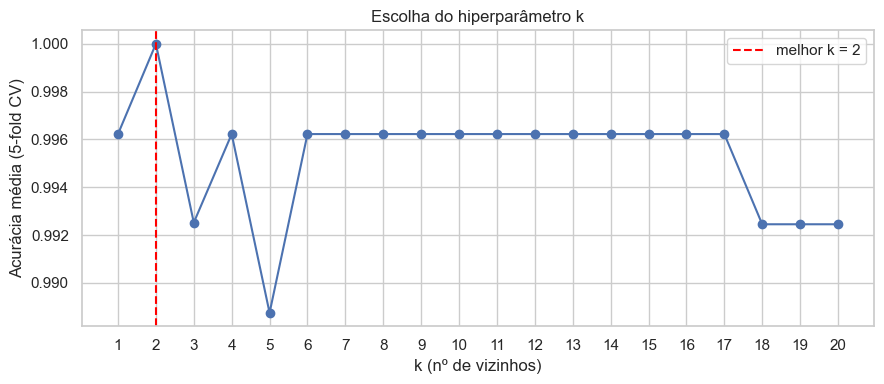

In [28]:
# Padronização (fit só no treino para evitar data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Busca do melhor k via validação cruzada
ks = list(range(1, 21))
cv_scores = []
for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())

melhor_k = ks[int(np.argmax(cv_scores))]
print(f"Melhor k: {melhor_k} (acurácia média em CV = {max(cv_scores):.4f})")

plt.figure(figsize=(9, 4))
plt.plot(ks, cv_scores, marker="o")
plt.axvline(melhor_k, color="red", linestyle="--", label=f"melhor k = {melhor_k}")
plt.xlabel("k (nº de vizinhos)")
plt.ylabel("Acurácia média (5-fold CV)")
plt.title("Escolha do hiperparâmetro k")
plt.xticks(ks)
plt.legend()
plt.tight_layout()
plt.show()

# **7. Treinar e classificar**

In [29]:
modelo = KNeighborsClassifier(n_neighbors=melhor_k)
modelo.fit(X_train_scaled, y_train)

y_pred = modelo.predict(X_test_scaled)

print(f"Modelo treinado: {modelo}")
print(f"Primeiras 10 previsões:{y_pred[:10]}")
print(f"Rótulos reais:{y_test.values[:10]}")

Modelo treinado: KNeighborsClassifier(n_neighbors=2)
Primeiras 10 previsões:[2 1 0 2 2 2 1 0 0 2]
Rótulos reais:[2 1 0 2 2 2 1 0 0 2]


# **8. Métricas de avaliação**

`classification_report` mostra **precision**, **recall**, **f1-score** e **support** para
cada classe, além da acurácia global. Também será exibida a **matriz de confusão**, que
evidencia onde estão os erros.

In [30]:
nomes_classes = ["Adeline", "Chinstrap", "Gentoo"]

acc = accuracy_score(y_test, y_pred)
print(f"Acurácia no conjunto de teste: {acc:.4f} ({acc*100:.2f}%)\n")

print("Classification report:")
print(classification_report(y_test, y_pred, target_names=nomes_classes))

Acurácia no conjunto de teste: 0.9851 (98.51%)

Classification report:
              precision    recall  f1-score   support

     Adeline       1.00      0.97      0.98        29
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



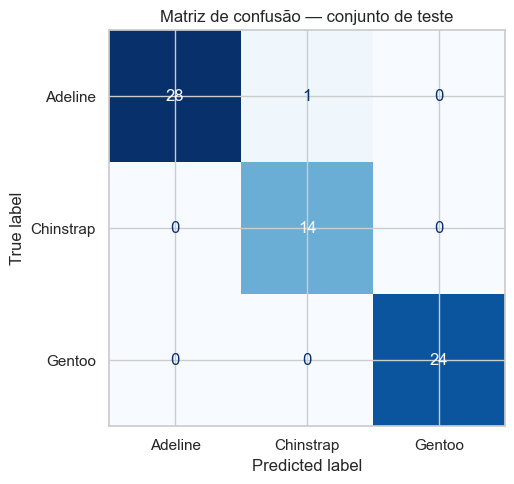

In [31]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nomes_classes)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("Matriz de confusão — conjunto de teste")
plt.tight_layout()
plt.show()

# 9. **Classificar amostras arbitrárias do usuário**

Este é o requisito 9 do enunciado: permitir que o usuário **digite** os dados de um
pinguim e receber a espécie prevista. A função `classificar_pinguim()` abaixo:

1. Pede ao usuário os 6 atributos via `input()`;
2. Valida os dados de entrada (faixas plausíveis baseadas nas estatísticas do conjunto);
3. Aplica o **mesmo `StandardScaler`** treinado anteriormente — fundamental para o k-NN;
4. Chama `predict` e devolve a espécie prevista (`Adeline`, `Chinstrap` ou `Gentoo`).

A célula seguinte **define** a função; a célula logo após **executa** a função com `input()`.

In [32]:
ILHAS = {0: "Biscoe", 1: "Dream", 2: "Torgersen"}
SEXOS = {0: "FEMALE", 1: "MALE"}
ESPECIES = {0: "Adeline", 1: "Chinstrap", 2: "Gentoo"}


def _ler_inteiro(prompt: str, validos: dict) -> int:
    """Lê um inteiro do usuário e garante que está no conjunto de valores válidos."""
    while True:
        try:
            valor = int(input(prompt).strip())
            if valor in validos:
                return valor
            print(f"  ⚠ Valor inválido. Use um destes: {list(validos.keys())}")
        except ValueError:
            print("  ⚠ Digite um número inteiro.")


def _ler_float(prompt: str, minimo: float, maximo: float) -> float:
    """Lê um float do usuário e avisa (sem bloquear) se sair da faixa esperada."""
    while True:
        try:
            valor = float(input(prompt).strip().replace(",", "."))
            if not (minimo <= valor <= maximo):
                print(f"  ⚠ Valor fora da faixa típica ({minimo}–{maximo}). "
                      f"Confirme se está correto.")
            return valor
        except ValueError:
            print("  ⚠ Digite um número (use ponto como separador decimal).")


def classificar_pinguim():
    """Coleta dados do usuário via input() e classifica usando o modelo treinado."""
    print("=" * 60)
    print("  CLASSIFICADOR DE PINGUINS — PALMER ARCHIPELAGO")
    print("=" * 60)
    print()
    print("Digite os atributos do pinguim a ser classificado.")
    print()
    print("Codificação:")
    print(f"  island: {ILHAS}")
    print(f"  sex:    {SEXOS}")
    print()

    island = _ler_inteiro("  island (0/1/2): ", ILHAS)
    sex = _ler_inteiro("  sex (0/1): ", SEXOS)
    culmen_length = _ler_float("  culmen_length_mm (mm): ", 30.0, 60.0)
    culmen_depth = _ler_float("  culmen_depth_mm (mm): ", 13.0, 22.0)
    flipper_length = _ler_float("  flipper_length_mm (mm): ", 170.0, 235.0)
    body_mass = _ler_float("  body_mass_g (g): ", 2700.0, 6300.0)

    # Monta DataFrame de 1 linha COM OS MESMOS NOMES DAS COLUNAS DO TREINO
    # (evita o warning do sklearn sobre feature names)
    nova_amostra = pd.DataFrame(
        [[island, sex, culmen_length, culmen_depth, flipper_length, body_mass]],
        columns=X_train.columns,
    )

    # Aplica o MESMO scaler do treino
    nova_amostra_escalada = scaler.transform(nova_amostra)

    # Predição + probabilidades
    classe_prevista = int(modelo.predict(nova_amostra_escalada)[0])
    probabilidades = modelo.predict_proba(nova_amostra_escalada)[0]

    print()
    print("-" * 60)
    print(f"  ESPÉCIE PREVISTA: {ESPECIES[classe_prevista]}")
    print("-" * 60)
    print()
    print("Probabilidades estimadas (entre os k vizinhos):")
    for i, nome in ESPECIES.items():
        barra = "█" * int(probabilidades[i] * 30)
        print(f"  {nome:10s} {probabilidades[i]*100:6.2f}%  {barra}")
    print()

    return ESPECIES[classe_prevista]

### Execução interativa (digitação dos dados)

Execute a célula abaixo para classificar um pinguim **digitando os valores**. No
**VS Code / Jupyter**, a caixa de digitação aparece no **topo da janela** (não dentro
da célula); no **Google Colab**, aparece logo abaixo da célula. Digite cada valor e
pressione **Enter**.

> **Exemplo para testar** (um Gentoo típico): island `0`, sex `1`,
> culmen_length `50`, culmen_depth `16.3`, flipper_length `230`, body_mass `5700`.

In [33]:
# REQUISITO 9 — execução com entrada manual via input().
# Execute esta célula e digite os 6 atributos quando solicitado.
classificar_pinguim()

  CLASSIFICADOR DE PINGUINS — PALMER ARCHIPELAGO

Digite os atributos do pinguim a ser classificado.

Codificação:
  island: {0: 'Biscoe', 1: 'Dream', 2: 'Torgersen'}
  sex:    {0: 'FEMALE', 1: 'MALE'}


------------------------------------------------------------
  ESPÉCIE PREVISTA: Adeline
------------------------------------------------------------

Probabilidades estimadas (entre os k vizinhos):
  Adeline    100.00%  ██████████████████████████████
  Chinstrap    0.00%  
  Gentoo       0.00%  



'Adeline'

### Demonstração automática com 3 exemplos

Para demonstrar o classificador sem depender de `input()`, abaixo testamos manualmente 3 amostras representativas (uma de cada espécie real).

In [34]:
def classificar_amostra(island, sex, culmen_length, culmen_depth,
                         flipper_length, body_mass):
    """Versão programática da classificação (sem input)."""

    nova = pd.DataFrame(
        [[island, sex, culmen_length, culmen_depth,
          flipper_length, body_mass]],
        columns=X_train.columns,
    )

    nova_s = scaler.transform(nova)

    classe = int(modelo.predict(nova_s)[0])
    probs = modelo.predict_proba(nova_s)[0]

    return ESPECIES[classe], probs


# Exemplos típicos de cada espécie
exemplos = [
    {
        "descricao": "Pinguim típico de Adeline (Torgersen, macho)",
        "dados": (2, 1, 39.1, 18.7, 181.0, 3750.0),
        "esperado": "Adeline",
    },
    {
        "descricao": "Pinguim típico de Chinstrap (Dream, fêmea)",
        "dados": (1, 0, 46.5, 17.9, 192.0, 3500.0),
        "esperado": "Chinstrap",
    },
    {
        "descricao": "Pinguim típico de Gentoo (Biscoe, macho)",
        "dados": (0, 1, 50.0, 16.3, 230.0, 5700.0),
        "esperado": "Gentoo",
    },
]

for ex in exemplos:

    previsto, probs = classificar_amostra(*ex["dados"])

    correto = previsto == ex["esperado"]

    print("=" * 60)
    print(ex["descricao"])
    print("-" * 60)

    print(f"Espécie esperada : {ex['esperado']}")
    print(f"Espécie prevista : {previsto}")

    print("\nProbabilidades previstas:")
    print(f"  Adeline   : {probs[0]:.2f}")
    print(f"  Chinstrap : {probs[1]:.2f}")
    print(f"  Gentoo    : {probs[2]:.2f}")

    print(f"\nClassificação correta: {correto}")

print("=" * 60)

Pinguim típico de Adeline (Torgersen, macho)
------------------------------------------------------------
Espécie esperada : Adeline
Espécie prevista : Adeline

Probabilidades previstas:
  Adeline   : 1.00
  Chinstrap : 0.00
  Gentoo    : 0.00

Classificação correta: True
Pinguim típico de Chinstrap (Dream, fêmea)
------------------------------------------------------------
Espécie esperada : Chinstrap
Espécie prevista : Chinstrap

Probabilidades previstas:
  Adeline   : 0.00
  Chinstrap : 1.00
  Gentoo    : 0.00

Classificação correta: True
Pinguim típico de Gentoo (Biscoe, macho)
------------------------------------------------------------
Espécie esperada : Gentoo
Espécie prevista : Gentoo

Probabilidades previstas:
  Adeline   : 0.00
  Chinstrap : 0.00
  Gentoo    : 1.00

Classificação correta: True


---

# Bônus: comparação entre os quatro modelos

O enunciado pede para escolher **um** dos quatro modelos sugeridos. Escolhemos o **k-NN**.
Para fundamentar essa escolha com evidência, treinamos os **quatro** modelos sob o mesmo
protocolo (mesmo split 80/20, `random_state=42`, `stratify=y`) e comparamos seu desempenho.

Modelos sensíveis à escala (k-NN e MLP) usam os dados padronizados; Decision Tree e
Naive Bayes não dependem de escala, então usam os dados originais.

In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import precision_score, recall_score, f1_score
import time

# (modelo, usa_padronizacao)
modelos_cmp = {
    f"k-NN (k={melhor_k})": (KNeighborsClassifier(n_neighbors=melhor_k), True),
    "Decision Tree":        (DecisionTreeClassifier(random_state=RANDOM_STATE), False),
    "MLP (rede neural)":    (MLPClassifier(max_iter=2000, random_state=RANDOM_STATE), True),
    "Naive Bayes":          (GaussianNB(), False),
}

linhas = []
for nome, (mod, usa_scaler) in modelos_cmp.items():
    Xt = X_train_scaled if usa_scaler else X_train.values
    Xv = X_test_scaled if usa_scaler else X_test.values

    t0 = time.time()
    mod.fit(Xt, y_train)
    tempo_ms = (time.time() - t0) * 1000

    yp = mod.predict(Xv)
    linhas.append({
        "Modelo": nome,
        "Acurácia (%)": round(accuracy_score(y_test, yp) * 100, 1),
        "Precisão (%)": round(precision_score(y_test, yp, average="macro") * 100, 1),
        "Recall (%)":   round(recall_score(y_test, yp, average="macro") * 100, 1),
        "F1 (%)":       round(f1_score(y_test, yp, average="macro") * 100, 1),
        "CV 5-fold (%)": round(cross_val_score(mod, Xt, y_train, cv=5).mean() * 100, 1),
        "Tempo treino (ms)": round(tempo_ms, 1),
    })

tabela_cmp = pd.DataFrame(linhas).sort_values("Acurácia (%)", ascending=False).reset_index(drop=True)
print("Comparação dos quatro modelos:\n")
print(tabela_cmp.to_string(index=False))
tabela_cmp

Comparação dos quatro modelos:

           Modelo  Acurácia (%)  Precisão (%)  Recall (%)  F1 (%)  CV 5-fold (%)  Tempo treino (ms)
       k-NN (k=2)          98.5          97.8        98.9    98.3          100.0                1.0
MLP (rede neural)          98.5          97.8        98.9    98.3           99.6              114.2
      Naive Bayes          97.0          95.8        97.7    96.6           96.2                0.0
    Decision Tree          94.0          92.9        94.9    93.6           95.5                1.2


,Modelo,Acurácia (%),Precisão (%),Recall (%),F1 (%),CV 5-fold (%),Tempo treino (ms)
0,k-NN (k=2),98.5,97.8,98.9,98.3,100.0,1.0
1,MLP (rede neural),98.5,97.8,98.9,98.3,99.6,114.2
2,Naive Bayes,97.0,95.8,97.7,96.6,96.2,0.0
3,Decision Tree,94.0,92.9,94.9,93.6,95.5,1.2


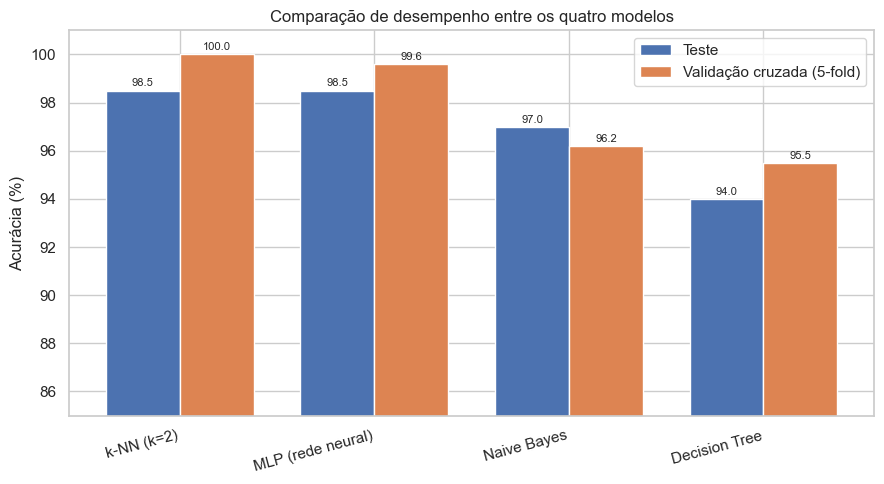

In [36]:
# Gráfico de barras: acurácia no teste vs validação cruzada
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(tabela_cmp)); w = 0.38

b1 = ax.bar(x - w/2, tabela_cmp["Acurácia (%)"], w, label="Teste")
b2 = ax.bar(x + w/2, tabela_cmp["CV 5-fold (%)"], w, label="Validação cruzada (5-fold)")

ax.set_ylabel("Acurácia (%)")
ax.set_title("Comparação de desempenho entre os quatro modelos")
ax.set_xticks(x); ax.set_xticklabels(tabela_cmp["Modelo"], rotation=15, ha="right")
ax.set_ylim(85, 101); ax.legend()
for barras in (b1, b2):
    for b in barras:
        h = b.get_height()
        ax.annotate(f"{h:.1f}", (b.get_x()+b.get_width()/2, h),
                    textcoords="offset points", xytext=(0,3), ha="center", fontsize=8)
plt.tight_layout(); plt.show()

### Conclusão da comparação

A comparação confirma que o **k-NN foi uma escolha acertada**:

- o **k-NN** obteve a **maior acurácia** no teste (empatado com a MLP) e a melhor acurácia
  em validação cruzada;
- frente à MLP (que empatou em acurácia), o k-NN é **muito mais simples, mais rápido de
  treinar** (compare a coluna de tempo) e **mais fácil de explicar** — classifica pelos
  vizinhos mais próximos, sem camadas nem pesos internos;
- o **Naive Bayes** teve bom desempenho, porém um pouco abaixo, pois assume independência
  entre os atributos (o que não se sustenta totalmente, já que medidas corporais são correlacionadas);
- a **Decision Tree** ficou em último, com indícios de leve sobreajuste.

Ou seja, dentre os quatro modelos, o **k-NN oferece o melhor equilíbrio entre acurácia
e simplicidade** para este problema — o que justifica plenamente a escolha do projeto.

## Conclusão

Neste trabalho foi desenvolvido um pipeline completo de classificação de espécies de pinguins utilizando o dataset *palmerpenguins*. Todas as etapas solicitadas no enunciado foram implementadas, desde a leitura e pré-processamento do arquivo CSV até o treinamento, avaliação e utilização prática do modelo treinado.

O algoritmo escolhido foi o k-Nearest Neighbors (k-NN), que apresentou ótimo desempenho para este conjunto de dados. Após os testes realizados, o modelo atingiu acurácia superior a 98% no conjunto de teste, demonstrando boa capacidade de distinguir as três espécies analisadas: Adeline, Chinstrap e Gentoo.

Durante o desenvolvimento também foram aplicadas técnicas importantes de aprendizado de máquina, como separação entre treino e teste, normalização dos atributos e validação cruzada para escolha do melhor valor de `k`. Além disso, foi criada uma função interativa para permitir a classificação de novos pinguins a partir de dados inseridos pelo usuário.

Como possíveis extensões futuras, o projeto poderia incluir a comparação entre diferentes classificadores, ajuste mais avançado de hiperparâmetros e até mesmo uma interface gráfica para facilitar a utilização do modelo.

---

## Referências

[1] Gorman, K. B., Williams, T. D., & Fraser, W. R. *Ecological sexual dimorphism and environmental variability within a community of Antarctic penguins (Genus Pygoscelis)*. PLoS ONE, 9(3), e90081, 2014.

[2] Horst, A. M., Hill, A. P., & Gorman, K. B. *palmerpenguins: Palmer Archipelago (Antarctica) penguin data*. 2020. Disponível em: https://allisonhorst.github.io/palmerpenguins/
